# CategoricalNB Model Training & Evaluation

Supports three dataset variants — set `VARIANT` in the config cell below:
- `"baseline"` → uses `x_train_categorized.csv` / `y_train.csv`
- `"undersampled"` → uses `x_train_undersampled.csv` / `y_train_undersampled.csv`
- `"oversampled"` → uses `x_train_oversampled.csv` / `y_train_oversampled.csv`

The **test set** (`x_test_categorized.csv` / `y_test.csv`) is shared across all variants.

**Pipeline:**
1. Set variant & load CSVs
2. Encode categories to integers
3. Train CategoricalNB model
4. Evaluate on test set (classification report, confusion matrix)

## 1. Setup & Imports

In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

## 2. Dataset Variant Config

Change `VARIANT` to switch which training data is used.
Valid values: `"baseline"`, `"undersampled"`, `"oversampled"`

In [ ]:
# ── Change this one line to switch datasets ──────────────────
VARIANT = "oversampled"   # "baseline" | "undersampled" | "oversampled"

TRAIN_X = {
    "baseline":     "x_train_categorized.csv",
    "undersampled": "x_train_undersampled.csv",
    "oversampled":  "x_train_oversampled.csv",
}
TRAIN_Y = {
    "baseline":     "y_train.csv",
    "undersampled": "y_train_undersampled.csv",
    "oversampled":  "y_train_oversampled.csv",
}

assert VARIANT in TRAIN_X, f"Unknown variant '{VARIANT}'. Choose: {list(TRAIN_X)}"
print(f"Running variant: {VARIANT}")
print(f"Train X : {TRAIN_X[VARIANT]}")
print(f"Train y : {TRAIN_Y[VARIANT]}")

Running variant: oversampled
Train X : x_train_oversampled.csv
Train y : y_train_oversampled.csv


## 3. Load Data

Loads training data for the selected variant and the shared test set.

In [3]:
X_train = pd.read_csv(TRAIN_X[VARIANT], dtype=str)
y_train = pd.read_csv(TRAIN_Y[VARIANT]).squeeze()
X_test  = pd.read_csv('x_test_categorized.csv', dtype=str)
y_test  = pd.read_csv('y_test.csv').squeeze()

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nTrain class distribution:')
print(y_train.value_counts().sort_index())

X_train: (799730, 6)  |  y_train: (799730,)
X_test:  (99999, 6)   |  y_test:  (99999,)

Train class distribution:
sleep_stage
0    159946
1    159946
2    159946
3    159946
5    159946
Name: count, dtype: int64


## 4. Encode Categories → Integers

`CategoricalNB` requires non-negative integer inputs.
We use `OrdinalEncoder` fitted on training data and applied to both train and test.

In [4]:
FEATURES = ['hr_mean', 'hr_sdnn_5', 'hr_slope_3', 'rr_mean', 'rr_slope_3', 'minutes_since_start']
STAGE_NAMES = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 5: 'REM'}

encoder = OrdinalEncoder(dtype=int)
X_train_enc = encoder.fit_transform(X_train[FEATURES])
X_test_enc  = encoder.transform(X_test[FEATURES])

print('Encoding complete.')
print(f'X_train_enc shape: {X_train_enc.shape}')
print(f'X_test_enc  shape: {X_test_enc.shape}')

print('\nCategory → Integer mapping:')
for feat, cats in zip(FEATURES, encoder.categories_):
    mapping = {cat: i for i, cat in enumerate(cats)}
    print(f'  {feat}: {mapping}')

Encoding complete.
X_train_enc shape: (799730, 6)
X_test_enc  shape: (99999, 6)

Category → Integer mapping:
  hr_mean: {'Bradycardia': 0, 'Normal': 1, 'Tachycardia': 2}
  hr_sdnn_5: {'High': 0, 'Low': 1, 'Moderate': 2}
  hr_slope_3: {'Decreasing': 0, 'Increasing': 1, 'Stable': 2}
  rr_mean: {'High': 0, 'Low': 1, 'Normal': 2}
  rr_slope_3: {'Decreasing': 0, 'Increasing': 1, 'Stable': 2}
  minutes_since_start: {'Early': 0, 'Late': 1, 'Mid': 2}


## 5. Train CategoricalNB

`alpha=1.0` (Laplace smoothing) — adds 1 to every count before computing probabilities.

In [5]:
model = CategoricalNB(alpha=1.0)
model.fit(X_train_enc, y_train)

print('Model trained successfully.')
print(f'Classes:  {model.classes_}')
print(f'Features: {model.n_features_in_}')

Model trained successfully.
Classes:  [0 1 2 3 5]
Features: 6


## 6. Evaluate on Test Set

In [6]:
y_pred = model.predict(X_test_enc)
target_names = [STAGE_NAMES[c] for c in model.classes_]

# --- Classification Report ---
print('=' * 60)
print(f'  CLASSIFICATION REPORT — {VARIANT.upper()}')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Summary Metrics ---
metrics_data = {
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 Score (weighted)'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df['Score'] = metrics_df['Score'].map(lambda x: f'{x:.4f}')
print('=' * 60)
print(f'  SUMMARY TABLE — {VARIANT.upper()}')
print('=' * 60)
display(metrics_df)

  CLASSIFICATION REPORT — OVERSAMPLED
              precision    recall  f1-score   support

        Wake       0.63      0.55      0.58     30883
          N1       0.10      0.26      0.14      4685
          N2       0.59      0.20      0.30     39985
          N3       0.24      0.63      0.35     11037
         REM       0.25      0.35      0.29     13409

    accuracy                           0.38     99999
   macro avg       0.36      0.40      0.33     99999
weighted avg       0.50      0.38      0.38     99999

  SUMMARY TABLE — OVERSAMPLED


,Metric,Score
0,Accuracy,0.3759
1,Precision (weighted),0.4952
2,Recall (weighted),0.3759
3,F1 Score (weighted),0.3826


## 7. Confusion Matrix

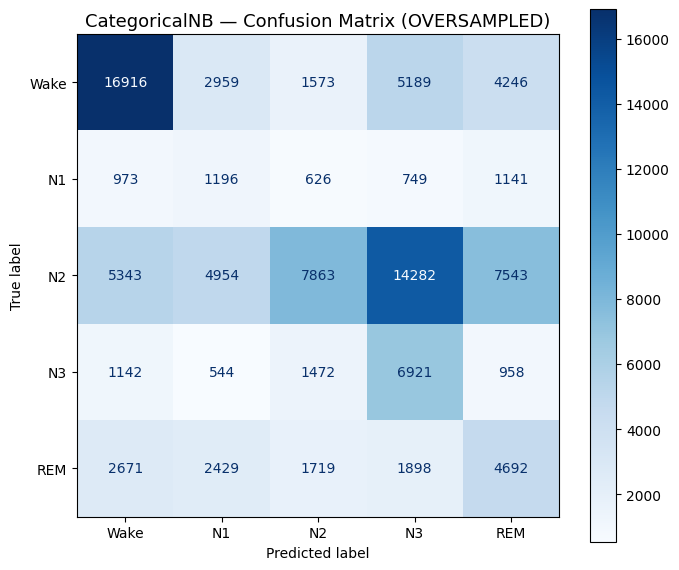

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=target_names,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'CategoricalNB — Confusion Matrix ({VARIANT.upper()})', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix Breakdown

Per-class True Positives, False Positives, False Negatives, and True Negatives.

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(f'Confusion Matrix Breakdown — {VARIANT.upper()}')
print('=' * 65)

for i, class_label in enumerate(model.classes_):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn

    name = STAGE_NAMES[class_label]
    print(f'\n  {name} (class {class_label}):')
    print(f'    True Positives  (correctly predicted {name}):     {tp:,}')
    print(f'    False Positives (incorrectly predicted {name}):   {fp:,}')
    print(f'    False Negatives (missed actual {name} cases):     {fn:,}')
    print(f'    True Negatives  (correctly predicted not {name}): {tn:,}')

Confusion Matrix Breakdown — OVERSAMPLED

  Wake (class 0):
    True Positives  (correctly predicted Wake):     16,916
    False Positives (incorrectly predicted Wake):   10,129
    False Negatives (missed actual Wake cases):     13,967
    True Negatives  (correctly predicted not Wake): 58,987

  N1 (class 1):
    True Positives  (correctly predicted N1):     1,196
    False Positives (incorrectly predicted N1):   10,886
    False Negatives (missed actual N1 cases):     3,489
    True Negatives  (correctly predicted not N1): 84,428

  N2 (class 2):
    True Positives  (correctly predicted N2):     7,863
    False Positives (incorrectly predicted N2):   5,390
    False Negatives (missed actual N2 cases):     32,122
    True Negatives  (correctly predicted not N2): 54,624

  N3 (class 3):
    True Positives  (correctly predicted N3):     6,921
    False Positives (incorrectly predicted N3):   22,118
    False Negatives (missed actual N3 cases):     4,116
    True Negatives  (correctly p

## 9. Export Naive Bayes Summary CSV

Generates a CSV matching the Naive Bayes summary table format:
- Per-feature likelihood tables: raw counts and conditional probabilities `count/total` per sleep stage
- Class priors block at the bottom

Uses the **training data** of the selected variant (`X_train` / `y_train`).

In [ ]:
# ── 9. Export Naive Bayes Summary CSV ─────────────────────────────────────
# Produces a CSV with the same layout as the NB summary table:
#   • One section per feature: category rows + Total row
#   • Raw counts per sleep stage (Wake, N1, N2, N3, REM)
#   • Conditional probability columns as 'count/total' fractions P(stage|feature=cat)
#   • Class Priors block appended at the bottom
# Uses the training data of the selected variant (X_train / y_train).

STAGE_KEYS  = list(model.classes_)           # e.g. [0, 1, 2, 3, 5]
STAGE_COLS  = [STAGE_NAMES[k] for k in STAGE_KEYS]   # ['Wake','N1','N2','N3','REM']
PROB_COLS   = [f'P({s})' for s in STAGE_COLS]

rows = []

for feat in FEATURES:
    feat_label = feat.replace('_', '_').title().replace('_', '_')  # keep original casing
    categories = sorted(X_train[feat].unique())
    first = True

    for cat in categories:
        row = {
            'Feature':  feat if first else '',
            'Category': cat,
        }
        first = False
        for sk, sn, pn in zip(STAGE_KEYS, STAGE_COLS, PROB_COLS):
            stage_mask  = (y_train == sk)
            count       = int(((X_train[feat] == cat) & stage_mask).sum())
            total       = int(stage_mask.sum())
            row[sn]     = count
            row[pn]     = f'{count}/{total}'
        rows.append(row)

    # Total row (class totals, no probability)
    total_row = {'Feature': '', 'Category': 'Total'}
    for sk, sn, pn in zip(STAGE_KEYS, STAGE_COLS, PROB_COLS):
        total_row[sn] = int((y_train == sk).sum())
        total_row[pn] = ''
    rows.append(total_row)
    rows.append({col: '' for col in ['Feature', 'Category'] + STAGE_COLS + PROB_COLS})  # blank spacer

# ── Class Priors block ────────────────────────────────────────────────────
total_train = len(y_train)
rows.append({'Feature': 'Class Priors', 'Category': '', **{c: '' for c in STAGE_COLS + PROB_COLS}})
rows.append({'Feature': 'sleep_stage',  'Category': 'Count', **{c: '' for c in STAGE_COLS},
             **{'P(Wake)': 'P(class)', **{p: '' for p in PROB_COLS[1:]}}})
for sk, sn in zip(STAGE_KEYS, STAGE_COLS):
    count = int((y_train == sk).sum())
    rows.append({'Feature': sn, 'Category': count,
                 **{c: '' for c in STAGE_COLS},
                 'P(Wake)': f'{count}/{total_train}',
                 **{p: '' for p in PROB_COLS[1:]}})

# ── Build DataFrame & save ────────────────────────────────────────────────
cols = ['Feature', 'Category'] + STAGE_COLS + PROB_COLS
summary_df = pd.DataFrame(rows, columns=cols)

out_path = f'nb_summary_{VARIANT}.csv'
summary_df.to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(summary_df)} rows)')
display(summary_df)
